# Encoder vs Decoder Split Across Suffix Steps

Extends the single-step analysis (notebook 03) by computing the encoder/decoder
attribution split **at every suffix step** until EOS is predicted.

Key questions:
1. Does the encoder's share change as the decoder generates more steps?
2. Which features shift between encoder- and decoder-driven across the suffix?

In [1]:
import sys
from pathlib import Path
_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir(): break
    _current = _current.parent
sys.path.insert(0, str(_current))
sys.path.insert(0, str(_current / 'src'))

import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm.notebook import tqdm
import random, pickle

from src.interpretability.config.bpic17_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

plt.style.use('seaborn-v0_8-whitegrid')
%matplotlib inline

SEED = CONFIG.seed
random.seed(SEED); np.random.seed(SEED); torch.manual_seed(SEED)

In [2]:
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)
eval_helper = Evaluation(
    model=model, dataset=test_dataset, concept_name=CONFIG.concept_name,
    growing_num_values=CONFIG.growing_num_values, all_cat=CONFIG.all_cat, all_num=CONFIG.all_num
)
tool = InterpretabilityTool(model, model.data_set_categories, device=device)

# EOS index for detecting end of suffix
cat_categories, _ = model.data_set_categories
activity_mapping = cat_categories[0][2]
idx_to_activity = {v: k for k, v in activity_mapping.items()}
eos_idx = activity_mapping.get('EOS', None)

print(f"Cases: {len(eval_helper.cases)}, EOS index: {eos_idx}")
print(f"Max decoder steps: {model.seq_len_pred}")

Data set categories:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('Action', 7, {'Created': 1, 'Deleted': 2, 'EOS': 3, 'Obtained': 4, 'Released': 5, 'statechange': 6}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 8, 'User_105': 9, 'User_106': 10, 'User_107': 11, 'User_108': 12, 'User_109': 13, 'User_11': 14, 'User_110': 15, 'U

Cases: 6301, EOS index: 11
Max decoder steps: 4


## Configuration

In [3]:
TEST_MODE = True
TEST_SAMPLE_SIZE = 20
IG_STEPS = 30  # Reduced for speed (full suffix × multiple steps)
TARGET = CONFIG.concept_name
MAX_SUFFIX_STEPS = model.seq_len_pred

DEC_FEATURE_SET = set(model.dec_feat[0]) | set(model.dec_feat[1])

print(f"Mode: {'TEST' if TEST_MODE else 'FULL'}, Samples: {TEST_SAMPLE_SIZE if TEST_MODE else 'ALL'}")
print(f"Max suffix steps: {MAX_SUFFIX_STEPS}")
print(f"Decoder features: {DEC_FEATURE_SET}")

Mode: TEST, Samples: 20
Max suffix steps: 4
Decoder features: {'lifecycle:transition', 'event_elapsed_time', 'org:resource', 'concept:name', 'case_elapsed_time'}


## Collect Samples

In [4]:
all_samples = []
for case_name, full_case in tqdm(eval_helper.cases.items(), desc="Collecting"):
    for prefix_len, prefix, suffix in eval_helper._iterate_case(full_case):
        if prefix_len >= 1:
            all_samples.append({
                'case_name': case_name, 'prefix_len': prefix_len,
                'prefix': prefix, 'suffix': suffix
            })

print(f"Total samples: {len(all_samples)}")
if TEST_MODE:
    samples = random.sample(all_samples, min(TEST_SAMPLE_SIZE, len(all_samples)))
else:
    samples = all_samples
print(f"Using {len(samples)} samples")

Collecting:   0%|          | 0/6301 [00:00<?, ?it/s]

Total samples: 233080
Using 20 samples


## Compute Encoder/Decoder Split Per Suffix Step

In [5]:
def get_predicted_class(tool, prefix_for_split, target, suffix_step, ig_steps):
    """Run a forward pass to get the predicted class index at a given suffix step."""
    wrapper = tool._get_or_create_wrapper(suffix_step)
    embedded_prefix = wrapper.embed_prefix(prefix_for_split)
    embedded_sos = wrapper.embed_sos(prefix_for_split)
    with torch.no_grad():
        preds = wrapper.forward(embedded_prefix, embedded_sos)
    # preds is a dict of tensors; get the target logits
    logits = preds[0][f'{target}_mean']
    if logits.dim() == 3:
        logits = logits[suffix_step]
    return logits.argmax(dim=-1).item()

results = []

for sample in tqdm(samples, desc="Computing splits across suffix steps"):
    try:
        prefix = sample['prefix']
        prefix_len = sample['prefix_len']

        cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
        num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
        process = (cat_tensors, num_tensors)
        actual_len, prefix_for_split = tool.extract_prefix_from_process(process, prefix_len)

        for suffix_step in range(MAX_SUFFIX_STEPS):
            # Get prediction at this step
            pred_idx = get_predicted_class(tool, prefix_for_split, TARGET, suffix_step, IG_STEPS)
            pred_activity = idx_to_activity.get(pred_idx, f'?{pred_idx}')

            # Compute encoder/decoder split
            split = tool.compute_encoder_decoder_attribution_split(
                prefix=prefix_for_split,
                target_output=TARGET,
                target_value='auto',
                suffix_step=suffix_step,
                n_steps=IG_STEPS
            )

            enc_totals = split['encoder_feature_totals']
            dec_totals = split['decoder_sos_feature_totals']

            # Per-feature breakdown
            for feat in enc_totals:
                enc_val = enc_totals.get(feat, 0)
                dec_val = dec_totals.get(feat, 0)
                feat_total = enc_val + dec_val
                feat_in_decoder = feat in dec_totals

                if feat_total > 0:
                    enc_frac = enc_val / feat_total
                elif not feat_in_decoder:
                    enc_frac = 1.0
                else:
                    enc_frac = 0.5

                results.append({
                    'case_name': sample['case_name'],
                    'prefix_len': prefix_len,
                    'suffix_step': suffix_step,
                    'feature': feat,
                    'encoder_attribution': enc_val,
                    'decoder_attribution': dec_val,
                    'total_attribution': feat_total,
                    'encoder_fraction': enc_frac,
                    'predicted': pred_activity,
                    'predicted_idx': pred_idx,
                    'overall_enc_frac': split['encoder_fraction']
                })

            # Stop if EOS predicted
            if eos_idx is not None and pred_idx == eos_idx:
                break

    except Exception as e:
        print(f"Error for {sample['case_name']} step {suffix_step}: {e}")

df = pd.DataFrame(results)
print(f"\nTotal records: {len(df)}")
print(f"Suffix steps reached: {df.groupby('suffix_step').size().to_dict()}")

Computing splits across suffix steps:   0%|          | 0/20 [00:00<?, ?it/s]


Total records: 1422
Suffix steps reached: {0: 360, 1: 360, 2: 360, 3: 342}


## Overall Encoder Fraction by Suffix Step

Overall Encoder Fraction by Suffix Step:
  Step 0: 61.1% ± 14.5%  (n=20)
  Step 1: 66.1% ± 14.7%  (n=20)
  Step 2: 71.9% ± 10.1%  (n=20)
  Step 3: 72.3% ± 8.2%  (n=19)


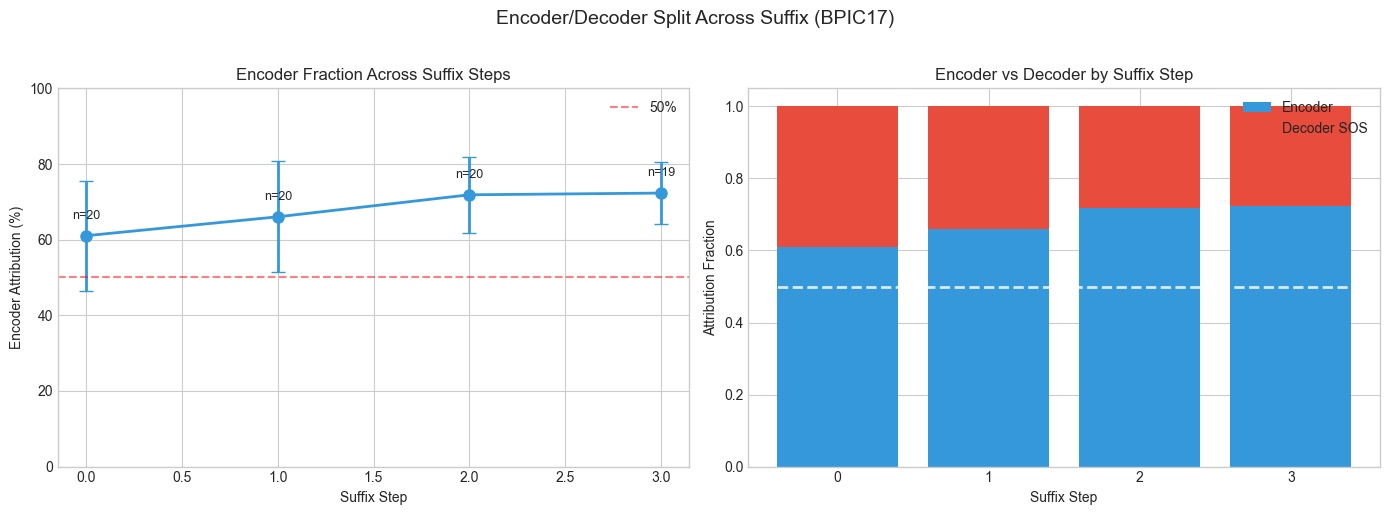

In [6]:
# One row per (sample, suffix_step) for overall split
overall = df.groupby(['case_name', 'prefix_len', 'suffix_step']).first().reset_index()

step_stats = overall.groupby('suffix_step')['overall_enc_frac'].agg(['mean', 'std', 'count'])
step_stats.columns = ['mean', 'std', 'n']

print("Overall Encoder Fraction by Suffix Step:")
print("=" * 60)
for step, row in step_stats.iterrows():
    print(f"  Step {step}: {row['mean']*100:.1f}% ± {row['std']*100:.1f}%  (n={int(row['n'])})")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Line plot
ax = axes[0]
ax.errorbar(step_stats.index, step_stats['mean']*100, yerr=step_stats['std']*100,
            marker='o', capsize=5, linewidth=2, markersize=8, color='#3498db')
ax.axhline(y=50, color='red', linestyle='--', alpha=0.5, label='50%')
ax.set_xlabel('Suffix Step')
ax.set_ylabel('Encoder Attribution (%)')
ax.set_title('Encoder Fraction Across Suffix Steps')
ax.set_ylim(0, 100)
ax.legend()
for step, row in step_stats.iterrows():
    ax.annotate(f'n={int(row["n"])}', (step, row['mean']*100),
                textcoords='offset points', xytext=(0, 12), ha='center', fontsize=9)

# Stacked bar
ax = axes[1]
x = step_stats.index.values
enc_means = step_stats['mean'].values
dec_means = 1 - enc_means
ax.bar(x, enc_means, label='Encoder', color='#3498db')
ax.bar(x, dec_means, bottom=enc_means, label='Decoder SOS', color='#e74c3c')
ax.axhline(y=0.5, color='white', linestyle='--', linewidth=2, alpha=0.8)
ax.set_xlabel('Suffix Step')
ax.set_ylabel('Attribution Fraction')
ax.set_title('Encoder vs Decoder by Suffix Step')
ax.set_xticks(x)
ax.legend()

plt.suptitle(f'Encoder/Decoder Split Across Suffix ({CONFIG.dataset_name})', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## Per-Feature Encoder Fraction by Suffix Step

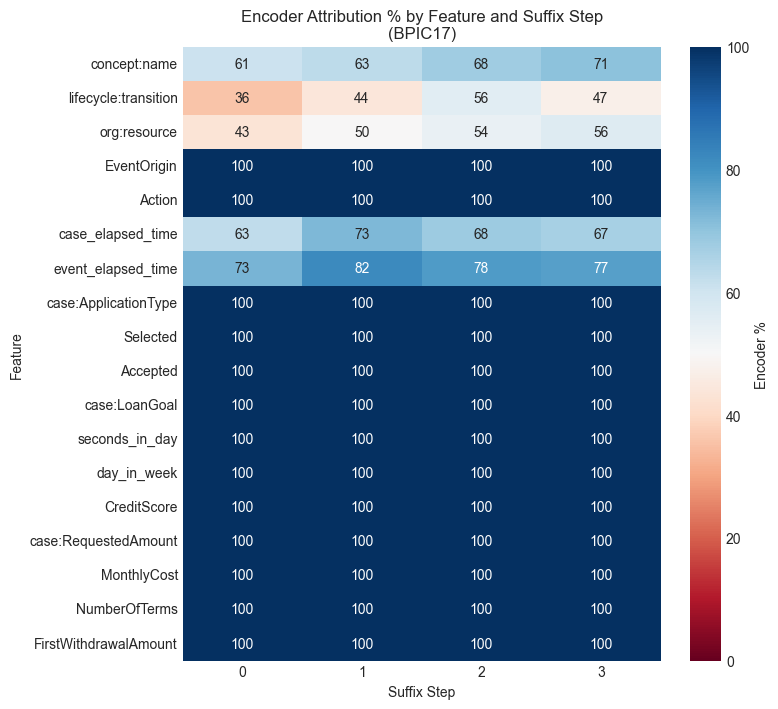

In [7]:
# Compute mean encoder fraction per (feature, suffix_step)
feat_step = df.groupby(['feature', 'suffix_step']).agg({
    'encoder_fraction': 'mean',
    'total_attribution': 'mean'
}).reset_index()

# Pivot for heatmap
pivot = feat_step.pivot(index='feature', columns='suffix_step', values='encoder_fraction')

# Sort features by total attribution (descending)
feat_importance = df.groupby('feature')['total_attribution'].mean().sort_values(ascending=False)
pivot = pivot.reindex(feat_importance.index)

fig, ax = plt.subplots(figsize=(8, max(6, len(pivot) * 0.4)))
sns.heatmap(pivot * 100, annot=True, fmt='.0f', cmap='RdBu', center=50,
            vmin=0, vmax=100, ax=ax, cbar_kws={'label': 'Encoder %'})
ax.set_xlabel('Suffix Step')
ax.set_ylabel('Feature')
ax.set_title(f'Encoder Attribution % by Feature and Suffix Step\n({CONFIG.dataset_name})')
plt.tight_layout()
plt.show()

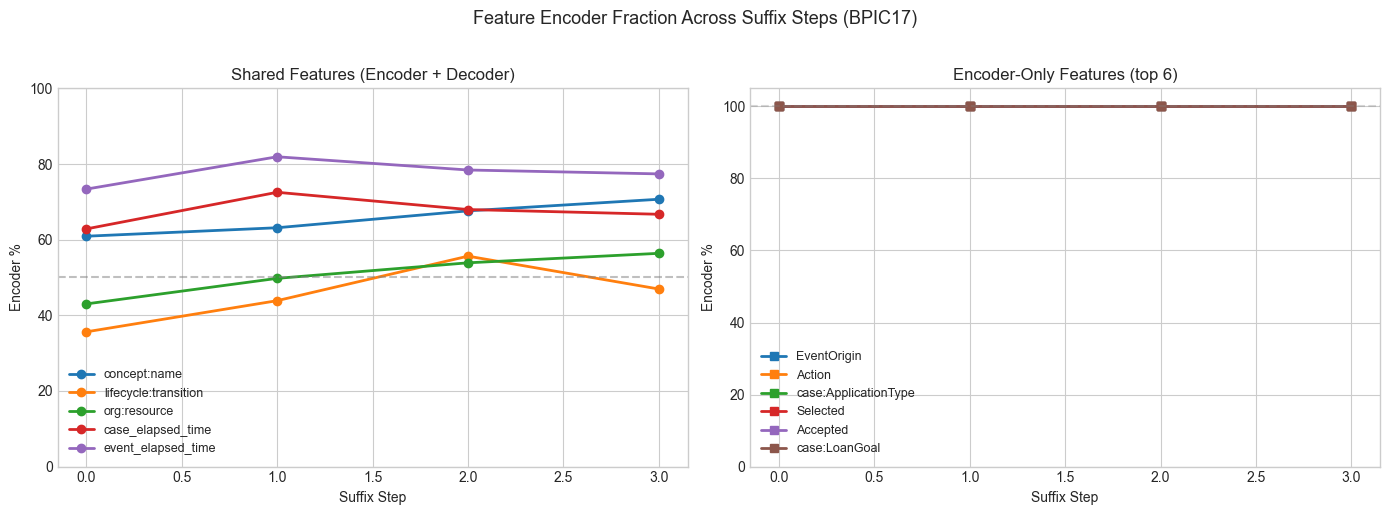

In [8]:
# Line plots per feature: encoder fraction across suffix steps
# Only show features present in both encoder and decoder (interesting ones)
shared_features = [f for f in feat_importance.index if f in DEC_FEATURE_SET]
encoder_only = [f for f in feat_importance.index if f not in DEC_FEATURE_SET]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Shared features (have both encoder and decoder paths)
ax = axes[0]
for feat in shared_features:
    feat_data = feat_step[feat_step['feature'] == feat].sort_values('suffix_step')
    ax.plot(feat_data['suffix_step'], feat_data['encoder_fraction'] * 100,
            marker='o', linewidth=2, label=feat)
ax.axhline(y=50, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Suffix Step')
ax.set_ylabel('Encoder %')
ax.set_title('Shared Features (Encoder + Decoder)')
ax.set_ylim(0, 100)
ax.legend(fontsize=9)

# Encoder-only features (top 6 by attribution)
ax = axes[1]
for feat in encoder_only[:6]:
    feat_data = feat_step[feat_step['feature'] == feat].sort_values('suffix_step')
    ax.plot(feat_data['suffix_step'], feat_data['encoder_fraction'] * 100,
            marker='s', linewidth=2, label=feat)
ax.axhline(y=100, color='gray', linestyle='--', alpha=0.3)
ax.set_xlabel('Suffix Step')
ax.set_ylabel('Encoder %')
ax.set_title('Encoder-Only Features (top 6)')
ax.set_ylim(0, 105)
ax.legend(fontsize=9)

plt.suptitle(f'Feature Encoder Fraction Across Suffix Steps ({CONFIG.dataset_name})', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

## Attribution Magnitude by Suffix Step

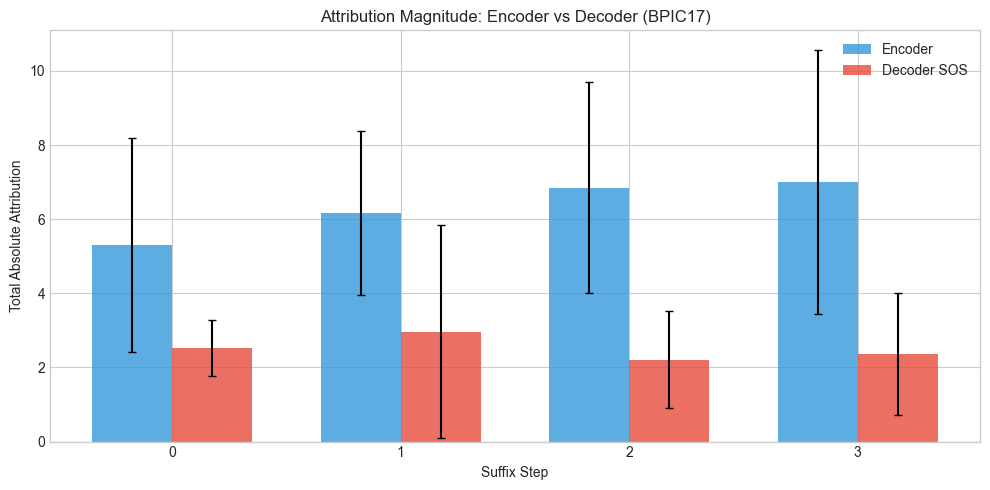

In [9]:
# Total attribution magnitude per suffix step (encoder vs decoder)
mag = df.groupby(['case_name', 'prefix_len', 'suffix_step']).agg({
    'encoder_attribution': 'sum',
    'decoder_attribution': 'sum'
}).reset_index()

mag_step = mag.groupby('suffix_step').agg({
    'encoder_attribution': ['mean', 'std'],
    'decoder_attribution': ['mean', 'std']
})
mag_step.columns = ['enc_mean', 'enc_std', 'dec_mean', 'dec_std']

fig, ax = plt.subplots(figsize=(10, 5))
x = mag_step.index.values
width = 0.35
ax.bar(x - width/2, mag_step['enc_mean'], width, yerr=mag_step['enc_std'],
       label='Encoder', color='#3498db', alpha=0.8, capsize=3)
ax.bar(x + width/2, mag_step['dec_mean'], width, yerr=mag_step['dec_std'],
       label='Decoder SOS', color='#e74c3c', alpha=0.8, capsize=3)
ax.set_xlabel('Suffix Step')
ax.set_ylabel('Total Absolute Attribution')
ax.set_title(f'Attribution Magnitude: Encoder vs Decoder ({CONFIG.dataset_name})')
ax.set_xticks(x)
ax.legend()
plt.tight_layout()
plt.show()

## Predicted Activities by Suffix Step

In [10]:
# What does the model predict at each step?
pred_per_step = overall.groupby(['suffix_step', 'predicted']).size().reset_index(name='count')
pred_per_step = pred_per_step.sort_values(['suffix_step', 'count'], ascending=[True, False])

for step in sorted(overall['suffix_step'].unique()):
    step_preds = pred_per_step[pred_per_step['suffix_step'] == step].head(5)
    total = step_preds['count'].sum()
    print(f"\nSuffix step {step} (n={int(overall[overall['suffix_step']==step].shape[0])}):")
    for _, row in step_preds.iterrows():
        pct = 100 * row['count'] / total
        eos_marker = ' <<< EOS' if row['predicted'] == 'EOS' else ''
        print(f"  {row['predicted']:30s}: {row['count']:3d} ({pct:5.1f}%){eos_marker}")


Suffix step 0 (n=20):
  W_Validate application        :   5 ( 27.8%)
  W_Call incomplete files       :   4 ( 22.2%)
  W_Complete application        :   4 ( 22.2%)
  W_Call after offers           :   3 ( 16.7%)
  W_Handle leads                :   2 ( 11.1%)

Suffix step 1 (n=20):
  W_Validate application        :   5 ( 31.2%)
  W_Complete application        :   4 ( 25.0%)
  W_Call incomplete files       :   3 ( 18.8%)
  W_Call after offers           :   2 ( 12.5%)
  W_Handle leads                :   2 ( 12.5%)

Suffix step 2 (n=20):
  W_Validate application        :   6 ( 37.5%)
  W_Call incomplete files       :   4 ( 25.0%)
  W_Call after offers           :   2 ( 12.5%)
  W_Complete application        :   2 ( 12.5%)
  W_Handle leads                :   2 ( 12.5%)

Suffix step 3 (n=19):
  W_Call incomplete files       :   5 ( 29.4%)
  W_Validate application        :   5 ( 29.4%)
  W_Complete application        :   4 ( 23.5%)
  W_Call after offers           :   2 ( 11.8%)
  A_Accepted   

## Summary

In [11]:
print("=" * 80)
print("SUMMARY: Encoder/Decoder Split Across Suffix Steps")
print("=" * 80)
print(f"\nDataset: {CONFIG.dataset_name}")
print(f"Mode: {'TEST' if TEST_MODE else 'FULL'}, Samples: {len(samples)}")
print(f"Max suffix steps: {MAX_SUFFIX_STEPS}")

print(f"\n--- Encoder Fraction by Suffix Step ---")
for step, row in step_stats.iterrows():
    print(f"  Step {step}: {row['mean']*100:.1f}% encoder  (n={int(row['n'])})")

# Trend
if len(step_stats) > 1:
    first = step_stats.iloc[0]['mean']
    last = step_stats.iloc[-1]['mean']
    if last > first + 0.05:
        trend = "INCREASES"
    elif last < first - 0.05:
        trend = "DECREASES"
    else:
        trend = "stays STABLE"
    print(f"\n  Trend: Encoder share {trend} across suffix steps ({first*100:.1f}% -> {last*100:.1f}%)")

print(f"\n--- Shared Features (shift across steps) ---")
for feat in shared_features:
    feat_data = feat_step[feat_step['feature'] == feat].sort_values('suffix_step')
    vals = feat_data['encoder_fraction'].values * 100
    if len(vals) > 1:
        print(f"  {feat:25s}: {' -> '.join(f'{v:.0f}%' for v in vals)}")

SUMMARY: Encoder/Decoder Split Across Suffix Steps

Dataset: BPIC17
Mode: TEST, Samples: 20
Max suffix steps: 4

--- Encoder Fraction by Suffix Step ---
  Step 0: 61.1% encoder  (n=20)
  Step 1: 66.1% encoder  (n=20)
  Step 2: 71.9% encoder  (n=20)
  Step 3: 72.3% encoder  (n=19)

  Trend: Encoder share INCREASES across suffix steps (61.1% -> 72.3%)

--- Shared Features (shift across steps) ---
  concept:name             : 61% -> 63% -> 68% -> 71%
  lifecycle:transition     : 36% -> 44% -> 56% -> 47%
  org:resource             : 43% -> 50% -> 54% -> 56%
  case_elapsed_time        : 63% -> 73% -> 68% -> 67%
  event_elapsed_time       : 73% -> 82% -> 78% -> 77%


In [12]:
output_dir = CONFIG.get_results_dir()
mode_suffix = '_test' if TEST_MODE else '_full'
output_path = output_dir / f'encoder_decoder_split_by_suffix_step{mode_suffix}.pkl'

with open(output_path, 'wb') as f:
    pickle.dump({
        'df': df,
        'step_stats': step_stats,
        'feat_step': feat_step,
        'config': CONFIG.to_dict(),
        'test_mode': TEST_MODE
    }, f)

print(f"Results saved to: {output_path}")

Results saved to: /Users/philippeichhorn/IdeaProjects/XAI-Probabilistic_Suffix_Prediction_U-ED-LSTM_pub/src/interpretability/notebooks/results/bpic17/encoder_decoder_split_by_suffix_step_test.pkl
